# LABORATORIO 04 GRUPO 1 Regresión Lineal Multiple
Cruz Grimaldez Manuel Dominique
En este caso regularizaremos los datos


In [20]:
#regresion lineal simple
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# utilizado para manejos de directorios y rutas
import os

#utilizando para trabajar con datos en xlsx
import pandas as pd
import matplotlib.pyplot as plt

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

from sklearn.model_selection import train_test_split
import tabulate



# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

## Separacion de datos a usar

In [22]:
# Cargar datos
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/preapuntes IA/Mi repositorio/Laboratorios/Lab4/Sensorless_drive_diagnosis.txt", sep=" ")

# Asumiendo que la última columna es la variable objetivo y las demás son características
X_data = df.iloc[:, :-1].values
y_data = df.iloc[:, -1].values

# Eliminar filas con valores NaN si existen
df = df.dropna()

train_dataset, test_dataset = train_test_split(df, test_size=0.2, random_state=42)

# Separar características (X) y variable objetivo (y) para los conjuntos de entrenamiento y prueba
X_regre = train_dataset.iloc[:, :-1].values
y_regre = train_dataset.iloc[:, -1].values

X_regre_test = test_dataset.iloc[:, :-1].values
y_regre_test = test_dataset.iloc[:, -1].values

m_regre = y_regre.size

# imprimir algunos puntos de datos (primeras 7 columnas y la última)
print('{:>8s}{:>8s}{:>10s}{:>15s}{:>8s}{:>10s}{:>8s}{:>8s}'.format('X[:,0]', 'X[:, 1]', 'X[:, 2]', 'X[:, 3]', 'X[:, 4]', 'X[:, 5]', 'X[:, 6]', 'y'))
print('-'*200)
for i in range(10):
    print('{:8.3f}{:8.3f}{:10.3f}{:15.3f}{:15.3f}{:15.3f}{:15.3f}{:8.3f}'.format(X_regre[i, 0], X_regre[i, 1], X_regre[i, 2], X_regre[i, 3], X_regre[i, 4], X_regre[i, 5], X_regre[i, 6], y_regre[i]))

  X[:,0] X[:, 1]   X[:, 2]        X[:, 3] X[:, 4]   X[:, 5] X[:, 6]       y
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  -0.000  -0.000     0.000         -0.000          0.000          0.000          0.030   5.000
   0.000   0.000    -0.000         -0.000         -0.000          0.000          0.006   3.000
  -0.000  -0.000    -0.000         -0.000         -0.000         -0.000          0.025   6.000
   0.000   0.000    -0.000         -0.000         -0.000         -0.000          0.011   4.000
   0.000   0.000    -0.000          0.000          0.000         -0.000         -0.018  10.000
  -0.000   0.000     0.000         -0.000          0.000          0.000          0.011   3.000
   0.000   0.000    -0.000          0.000         -0.000         -0.000          0.008   9.000
  -0.000   0.000    -0.000         -0.000         -0.000  

Para normalizar

In [23]:
#normalizamos las caracteristicas
def  featureNormalize(X):
    X_norm = X.copy()

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Asegúrate de evitar la división por cero al verificar si sigma es cero
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [24]:
# llama featureNormalize con los datos cargados
X_norm_regre, mu_regre, sigma_regre = featureNormalize(X_regre)

# print(X_regre)
# print('Media calculada:', mu_regre)
# print('Desviación estandar calculada:', sigma_regre)
# print(X_norm_regre)

print('{:>8s}{:>8s}{:>10s}{:>8s}{:>8s}{:>10s}{:>8s}'.format('X[:,0]', 'X[:, 1]', 'X[:, 2]', 'X[:, 3]', 'X[:, 4]', 'X[:, 5]', 'X[:, 6]'))
print('-'*200)
for i in range(10):
    print('{:8.3f}{:8.3f}{:10.9f}{:15.3f}{:15.3f}{:15.3f}{:15.3f}'.format(X_norm_regre[i, 0], X_norm_regre[i, 1], X_norm_regre[i, 2], X_norm_regre[i, 3], X_norm_regre[i, 4], X_norm_regre[i, 5], X_norm_regre[i, 6]))




  X[:,0] X[:, 1]   X[:, 2] X[:, 3] X[:, 4]   X[:, 5] X[:, 6]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  -0.168  -0.0640.578284608         -0.196          0.144          0.218          0.771
   0.250   0.040-0.018224967         -0.043         -0.097          1.442          0.112
   0.004  -0.041-0.248273515         -0.015         -0.163         -0.070          0.629
   0.202   0.134-0.445225882         -0.131         -1.220         -2.028          0.249
   0.085   0.275-0.355291204          0.030          0.820         -0.306         -0.550
  -0.087   2.5820.309068628          0.004          0.302          1.739          0.250
   0.051  -0.005-0.012110871          0.041         -0.050         -0.009          0.160
   0.042   0.104-0.196663249         -0.036         -0.035         -0.156          0.109
   0.139   1.1500.245852668 

In [25]:
# Creamos una funcion que nos ayude con las graficas de cada dato respecto a la Y predicha
def graficarDatos(x, y, xlabel, ylabel):
  fig = pyplot.figure()
  pyplot.plot(x, y, 'ro', ms=10, mec='k')

  pyplot.xlabel(xlabel)
  pyplot.ylabel(ylabel)

In [26]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X_ready_regre = np.concatenate([np.ones((m_regre, 1)), X_norm_regre], axis=1)

In [27]:
print('{:>8s}{:>8s}{:>10s}{:>8s}{:>8s}{:>10s}{:>8s}{:>8s}'.format('X[:,0]', 'X[:, 1]', 'X[:, 2]', 'X[:, 3]', 'X[:, 4]', 'X[:, 5]', 'X[:, 6]', 'X[:, 7]'))
print('-'*200)
for i in range(10):
    print('{:8.3f}{:8.3f}{:10.9f}{:15.3f}{:15.3f}{:15.3f}{:15.3f}'.format(X_ready_regre[i, 0], X_ready_regre[i, 1], X_ready_regre[i, 2], X_ready_regre[i, 3], X_ready_regre[i, 4], X_ready_regre[i, 5], X_ready_regre[i, 6], X_ready_regre[i, 7]))

  X[:,0] X[:, 1]   X[:, 2] X[:, 3] X[:, 4]   X[:, 5] X[:, 6] X[:, 7]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   1.000  -0.168-0.063674973          0.578         -0.196          0.144          0.218
   1.000   0.2500.039874709         -0.018         -0.043         -0.097          1.442
   1.000   0.004-0.041110640         -0.248         -0.015         -0.163         -0.070
   1.000   0.2020.133912998         -0.445         -0.131         -1.220         -2.028
   1.000   0.0850.274672026         -0.355          0.030          0.820         -0.306
   1.000  -0.0872.581928506          0.309          0.004          0.302          1.739
   1.000   0.051-0.004534019         -0.012          0.041         -0.050         -0.009
   1.000   0.0420.104340811         -0.197         -0.036         -0.035         -0.156
   1.000   0.1391.14971

In [28]:
import numpy as np

def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1 / (1 + np.exp(-z))

def calcularCosto(theta, X, y, lambda_):
    """
    Calcula el costo de usar theta como parametro para la regresion logistica y regularizacion.
    """
    m = y.size
    J = 0
    h = sigmoid(X.dot(theta))

    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h)) + (lambda_ / (2 * m)) * np.sum(np.square(theta[1:]))

    # return J, grad
    return J

In [29]:
def gradientDescentMulti(X, y, theta, alpha, num_iters, lambda_, num_labels):
    """
    Realiza el descenso por el gradiente para aprender theta para regresion logistica con multiples clases.
    Actualiza theta por num_iters iteraciones con paso alpha.
    """
    # Inicializa algunos valores
    m = X.shape[0] # numero de ejemplos de entrenamiento
    n = X.shape[1] # numero de caracteristicas + 1 (por el termino de intercepcion)
    J_history = []

    # Inicializa theta para todas las clases
    all_theta = np.zeros((num_labels, n))

    for c in range(1, num_labels + 1):
        # Para cada clase, entrenamos un clasificador logistico binario
        initial_theta = np.zeros(n)
        temp_theta = initial_theta.copy()
        temp_J_history = []

        # Convertir el problema a binario: 1 si es la clase actual (c), 0 en caso contrario
        binary_y = (y == c).astype(int)

        for i in range(num_iters):
            h = sigmoid(X.dot(temp_theta))

            # Calcular el gradiente
            gradient = (1 / m) * (X.T.dot(h - binary_y))
            # Añadir el término de regularización, excluyendo theta[0]
            gradient[1:] = gradient[1:] + (lambda_ / m) * temp_theta[1:]

            # Actualizar los parámetros theta
            temp_theta = temp_theta - alpha * gradient

            # Calcular el costo y almacenarlo (opcional, para visualizar la convergencia)
            cost = calcularCosto(temp_theta, X, binary_y, lambda_)
            temp_J_history.append(cost)

        all_theta[c-1, :] = temp_theta
        J_history.append(temp_J_history) # Almacena el historial de costo para cada clasificador binario

    return all_theta, J_history

#### Seleccionando coheficientes de aprendizaje


Los valores de theta calculados para cada clasificador son:
Clase 1: [-3.30153177e-01  4.99093522e-04  1.28965477e-02  8.52859736e-03
  1.18563484e-04  2.04621535e-02  6.49499235e-03  3.91445843e-02
  3.91260679e-02  3.90657733e-02 -3.02715911e-02 -3.02905345e-02
 -3.03138372e-02 -3.33290004e-04  2.76470841e-04  1.24618737e-03
 -1.61006231e-03 -1.78494375e-03  8.54846327e-04 -6.95511712e-03
 -6.95656836e-03 -6.95922686e-03 -6.75724724e-03 -6.75763819e-03
 -6.76069610e-03 -5.00955939e-03  5.68565128e-03  1.98333147e-03
 -3.29228496e-03  8.93724732e-03  1.07139910e-03  3.20865194e-03
  3.15498479e-03  3.25926938e-03  4.49919088e-03  4.40195626e-03
  4.44757795e-03  1.57265882e-04  1.50888206e-03 -2.06627582e-03
 -2.18910758e-05 -1.10051659e-03 -1.64706065e-03 -1.67638955e-02
 -1.68080458e-02 -1.68187708e-02  5.37390864e-03  5.34125473e-03
  5.67594057e-03]
Clase 2: [-0.33045837 -0.00358934  0.01658386  0.00431754 -0.00321182  0.01770065
  0.00497963 -0.04048696 -0.04051601 -0.04053977 -0

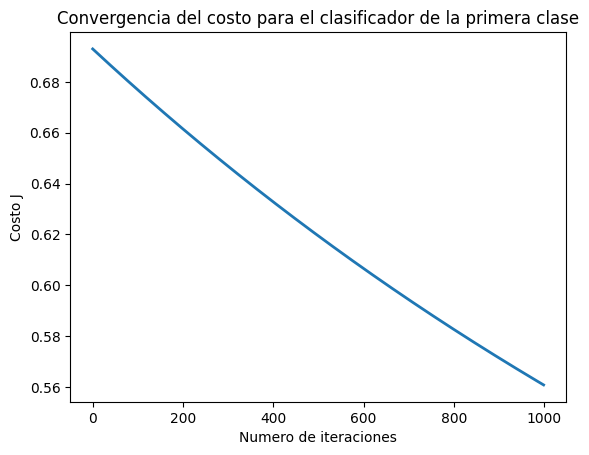

In [16]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.0009 # alpha = 0.003
num_iters = 1000 # Reducido para acelerar
lambda_ = 1000
num_labels = 11 # Número de clases en tu dataset

# inicializa theta y ejecuta el descenso por el gradiente
# Inicializamos all_theta con ceros para todas las clases
initial_theta = np.zeros(X_ready_regre.shape[1])
all_theta_regre, J_history_regre = gradientDescentMulti(X_ready_regre, y_regre, initial_theta, alpha, num_iters, lambda_, num_labels)

# Grafica la convergencia del costo para el primer clasificador (puedes graficar otros si deseas)
pyplot.plot(np.arange(len(J_history_regre[0])), J_history_regre[0], lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo para el clasificador de la primera clase')


print("Los valores de theta calculados para cada clasificador son:")
# Imprimir los thetas para cada clase
for c in range(num_labels):
    print(f"Clase {c+1}: {all_theta_regre[c, :]}")

# print("Los valores de theta calculados son:")
# i = 0
# for tht in theta_regre:
#     i += 1
#     print(f"theta {i}: {tht}")

In [30]:
#Creamos la funcion:
def mean_squared_error(y_pred, y_actual):
    resta = y_pred - y_actual
    err_cuadrado = np.sum(resta ** 2)
    return err_cuadrado / len(y_pred)

In [32]:
# Normalizar el conjunto de datos de prueba utilizando la media y desviación estándar del conjunto de entrenamiento
X_norm_regre_test = (X_regre_test - mu_regre) / sigma_regre

# Añadir el término de intersección a X_norm_regre_test
X_ready_test = np.concatenate([np.ones((X_norm_regre_test.shape[0], 1)), X_norm_regre_test], axis=1)

print("Primeros 10 ejemplos del conjunto de prueba normalizado (con término de intercepción):")
print('{:>8s}{:>8s}{:>10s}{:>8s}{:>8s}{:>10s}{:>8s}{:>8s}'.format('X[:,0]', 'X[:, 1]', 'X[:, 2]', 'X[:, 3]', 'X[:, 4]', 'X[:, 5]', 'X[:, 6]', 'X[:, 7]'))
print('-'*200)
for i in range(10):
    print('{:8.3f}{:8.3f}{:10.9f}{:15.3f}{:15.3f}{:15.3f}{:15.3f}{:8.3f}'.format(X_ready_test[i, 0], X_ready_test[i, 1], X_ready_test[i, 2], X_ready_test[i, 3], X_ready_test[i, 4], X_ready_test[i, 5], X_ready_test[i, 6], X_ready_test[i, 7]))

Primeros 10 ejemplos del conjunto de prueba normalizado (con término de intercepción):
  X[:,0] X[:, 1]   X[:, 2] X[:, 3] X[:, 4]   X[:, 5] X[:, 6] X[:, 7]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   1.000  -0.0410.009308973         -0.066         -0.106          0.184          0.039  -0.864
   1.000  -0.2040.640540842          0.318         -0.007          1.082         -7.829  -2.205
   1.000  -0.0100.430647229          3.952          0.062         -0.007          0.842   0.312
   1.000   0.009-0.051535208          0.071          0.046         -0.059         -0.132  -3.025
   1.000   0.193-0.402924888         -0.185         -0.078          0.318         -0.275  -0.526
   1.000  -0.0650.580089977         -0.248          0.003          0.190         -0.229   0.469
   1.000   0.0101.267314567          0.403         -0.016        

In [33]:
def predict_one_vs_all(all_theta, X):
    """
    Predice la etiqueta para un conjunto de datos X usando los parametros
    aprendidos con el enfoque one-vs-all.

    Parametros
    ----------
    all_theta : array_like
        Thetas entrenados para cada clase, de tamaño (num_labels, n).
    X : array_like
        Datos de entrada de tamaño (m, n), donde m es el numero de
        ejemplos y n es el numero de caracteristicas.

    Devuelve
    --------
    p : array_like
        Vector de predicciones para cada ejemplo en X. Contiene valores de 1 a
        num_labels.
    """
    m = X.shape[0]
    num_labels = all_theta.shape[0]

    # Puedes usar la funcion sigmoid de la parte anterior
    # para calcular la probabilidad de cada clase
    h = sigmoid(X.dot(all_theta.T))

    # Encuentra el indice de la maxima probabilidad para cada ejemplo
    p = np.argmax(h, axis=1)

    # argmax devuelve indices de 0 a num_labels-1, por lo que sumamos 1
    # para mapear a tus etiquetas de 1 a num_labels
    return p + 1

# Realizar predicciones en el conjunto de entrenamiento
p_train = predict_one_vs_all(all_theta_regre, X_ready_regre)

# Calcular la precisión en el conjunto de entrenamiento
print('Precision en el conjunto de entrenamiento: {:.2f} %'.format(np.mean(p_train == y_regre) * 100))

# Realizar predicciones en el conjunto de prueba
# Asegurarse de que X_ready_test ya fue normalizado y tiene el término de intercepción
# Esto se hizo en una celda generada anteriormente
p_test = predict_one_vs_all(all_theta_regre, X_ready_test)

# Calcular la precisión en el conjunto de prueba
print('Precision en el conjunto de prueba: {:.2f} %'.format(np.mean(p_test == y_regre_test) * 100))

Precision en el conjunto de entrenamiento: 33.73 %
Precision en el conjunto de prueba: 34.75 %


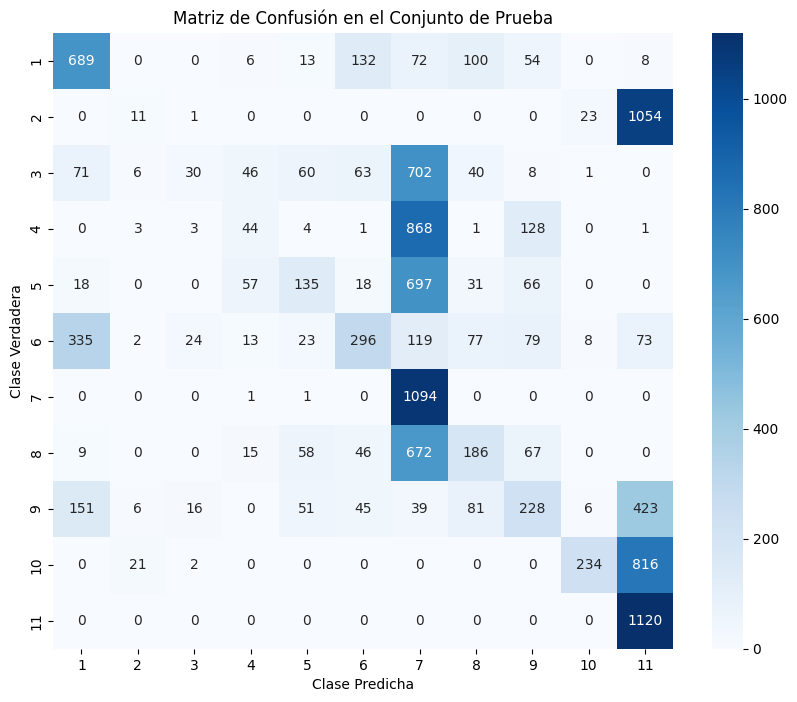

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calcular la matriz de confusión en el conjunto de prueba
cm = confusion_matrix(y_regre_test, p_test)

# Visualizar la matriz de confusión
pyplot.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(1, 12), yticklabels=np.arange(1, 12))
pyplot.xlabel('Clase Predicha')
pyplot.ylabel('Clase Verdadera')
pyplot.title('Matriz de Confusión en el Conjunto de Prueba')
pyplot.show()

In [35]:
# Seleccionar algunos ejemplos del conjunto de prueba para hacer predicciones
# Puedes cambiar los indices para seleccionar otros ejemplos
ejemplos_para_predecir = X_ready_test[:5]
etiquetas_reales = y_regre_test[:5]

# Realizar predicciones
predicciones = predict_one_vs_all(all_theta_regre, ejemplos_para_predecir)

# Mostrar las predicciones y compararlas con las etiquetas reales
print("Realizando predicciones en algunos ejemplos del conjunto de prueba:")
print("-" * 50)
for i in range(len(ejemplos_para_predecir)):
    print(f"Ejemplo {i+1}:")
    print(f"  Características (normalizadas + intercepción): {ejemplos_para_predecir[i]}")
    print(f"  Clase Verdadera: {etiquetas_reales[i]}")
    print(f"  Clase Predicha: {predicciones[i]}")
    print("-" * 50)

Realizando predicciones en algunos ejemplos del conjunto de prueba:
--------------------------------------------------
Ejemplo 1:
  Características (normalizadas + intercepción): [ 1.00000000e+00 -4.12436183e-02  9.30897260e-03 -6.64635748e-02
 -1.06143033e-01  1.83787933e-01  3.92644927e-02 -8.64474705e-01
 -8.64516770e-01 -8.63987390e-01 -1.32806719e-01 -1.32972287e-01
 -1.33115904e-01 -7.43722376e-01 -9.12679643e-01 -1.03160104e+00
 -7.42510362e-01 -8.19313554e-01 -1.00496056e+00 -1.29582208e+00
 -1.29575871e+00 -1.29530858e+00 -1.29694085e+00 -1.29688161e+00
 -1.29647712e+00 -1.58205329e-02  1.88155991e-01  1.85781859e-04
  7.55066927e-02  1.66333186e-02  1.02251652e-01 -8.07196908e-01
 -8.06972003e-01 -8.04869087e-01 -2.22992474e-01 -2.26756595e-01
 -2.31121841e-01 -9.29438002e-03 -5.66610892e-01 -8.77101487e-01
 -1.34722394e-02 -3.21794413e-01 -6.43899756e-01  1.32855269e-01
  1.39055511e-01  1.38511750e-01  9.34904022e-01  9.41479893e-01
  9.04269501e-01]
  Clase Verdadera: 10
 